In [2]:
import pandas as pd
import os
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import warnings

In [14]:
input_path_oct_data = r"D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/cleaned/csv/part-00000-dcfab4f6-e140-4ccc-aa05-98650d312d49-c000.csv"
oct_data = pd.read_csv(input_path_oct_data)

In [15]:
print(oct_data)

                          event_time_ts event_type  product_id  \
0         2019-09-30T22:39:37.000-04:00       view    32200019   
1         2019-09-30T23:28:23.000-04:00       view     3601475   
2         2019-09-30T22:44:57.000-04:00       view     4201337   
3         2019-09-30T22:44:42.000-04:00       view     4802930   
4         2019-09-30T23:37:16.000-04:00       view    14701162   
...                                 ...        ...         ...   
42349867  2019-10-23T08:29:43.000-04:00       view     3901194   
42349868  2019-10-26T22:53:02.000-04:00       view    12719872   
42349869  2019-10-21T07:20:08.000-04:00       view     1003195   
42349870  2019-10-10T23:31:48.000-04:00       view     6000157   
42349871  2019-10-18T14:29:56.000-04:00       view     8800939   

                                   category_code     brand   price    user_id  \
0                                     kids.swing   unknown  247.11  555465042   
1                      appliances.kitchen.was

## 2.9 Analysis of User Activity Trends

### 2.9.1 Analysis of Daily User Activity Trends

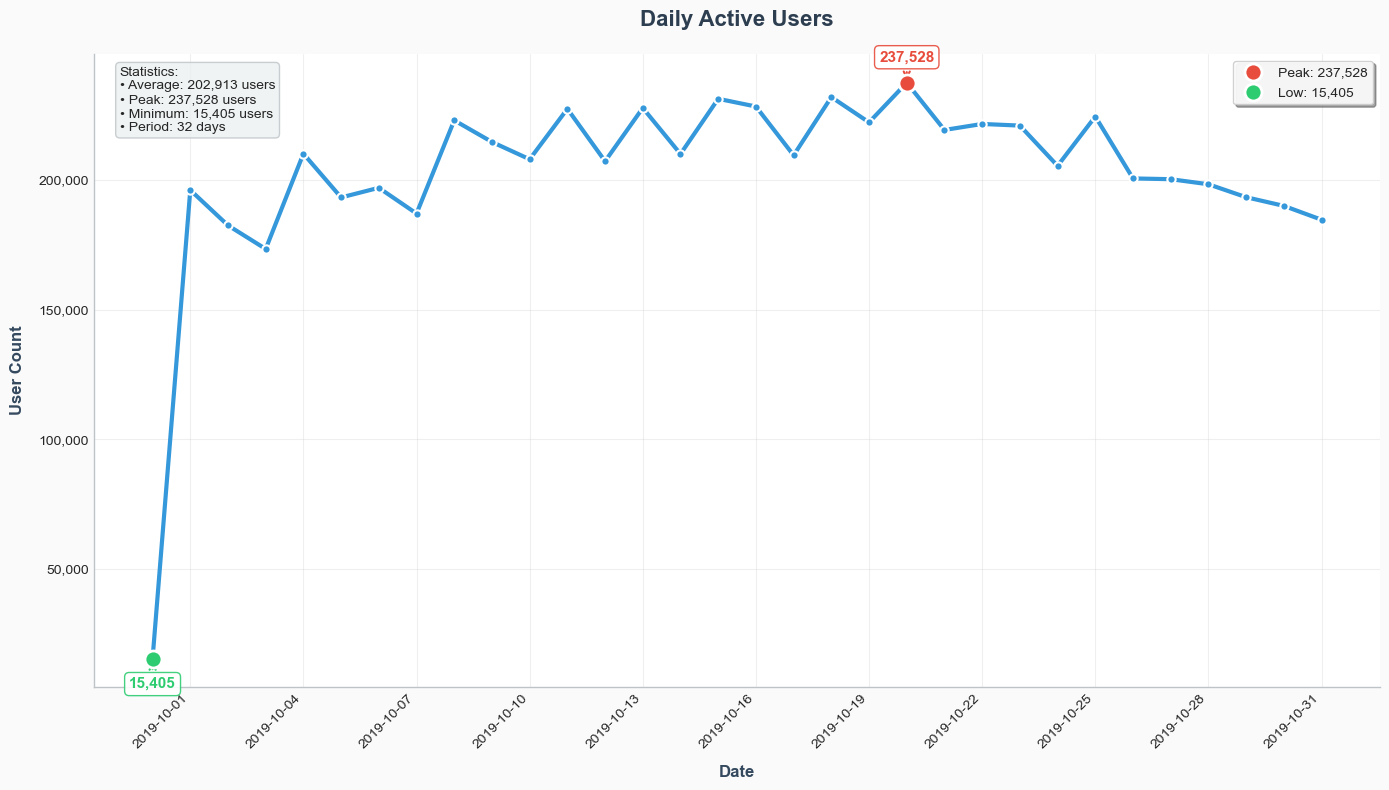

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime

# Set style for modern and clean appearance
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create figure with professional dimensions
plt.figure(figsize=(14, 8))
fig = plt.gcf()
fig.patch.set_facecolor('#fafafa')  # Light background for the figure

# Create axis with enhanced styling
ax = plt.gca()
ax.set_facecolor('#ffffff')  # White background for the plot area

# Calculate daily active users
user_counts = oct_data.groupby('date')['user_id'].nunique().rename('user_count').reset_index()

# Create enhanced line plot
line = sns.lineplot(data=user_counts, x='date', y='user_count', 
                   linewidth=3,        # Thicker line for better visibility
                   color='#3498db',    # Professional blue color
                   marker='o',         # Add markers for data points
                   markersize=6,       # Appropriate marker size
                   markeredgecolor='white',  # White border for markers
                   markeredgewidth=1.5,      # Border width
                   ax=ax)

# Set x-axis major tick interval
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Find max and min values
max_idx = user_counts['user_count'].idxmax()
min_idx = user_counts['user_count'].idxmin()

max_x, max_y = user_counts.loc[max_idx, ['date', 'user_count']]
min_x, min_y = user_counts.loc[min_idx, ['date', 'user_count']]

# Enhanced scatter points for extreme values
ax.scatter(max_x, max_y, color='#e74c3c', s=150, zorder=5, 
          label=f"Peak: {int(max_y):,}", 
          edgecolors='white', linewidth=2)
ax.scatter(min_x, min_y, color='#2ecc71', s=150, zorder=5, 
          label=f"Low: {int(min_y):,}", 
          edgecolors='white', linewidth=2)

# Enhanced annotations for extreme values
ax.annotate(f'{int(max_y):,}', 
           xy=(max_x, max_y), 
           xytext=(max_x, max_y + max_y * 0.03),
           ha='center', va='bottom', 
           fontsize=11, fontweight='bold', color='#e74c3c',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    alpha=0.9, edgecolor='#e74c3c'),
           arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

ax.annotate(f'{int(min_y):,}', 
           xy=(min_x, min_y), 
           xytext=(min_x, min_y - max_y * 0.03),
           ha='center', va='top', 
           fontsize=11, fontweight='bold', color='#2ecc71',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    alpha=0.9, edgecolor='#2ecc71'),
           arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5))

# Professional title
plt.title('Daily Active Users', 
          fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Enhanced axis labels
plt.xlabel('Date', fontsize=12, fontweight='semibold', color='#34495e', labelpad=10)
plt.ylabel('User Count', fontsize=12, fontweight='semibold', color='#34495e', labelpad=10)

# Format y-axis ticks with commas for thousands
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Enhanced grid
ax.grid(True, alpha=0.3)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Style the remaining spines
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Enhanced legend
plt.legend(loc='upper right', frameon=True, fancybox=True, 
          shadow=True, framealpha=0.9)

# Calculate and display statistics
total_days = len(user_counts)
avg_users = user_counts['user_count'].mean()
max_users = user_counts['user_count'].max()
min_users = user_counts['user_count'].min()

# Add statistics box
stats_text = f'Statistics:\n• Average: {avg_users:,.0f} users\n• Peak: {max_users:,.0f} users\n• Minimum: {min_users:,.0f} users\n• Period: {total_days} days'
props = dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8, edgecolor='#bdc3c7')
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()


### 2.9.2 Heatmap Analysis of User Activity by "Weekday-Hour"

In [18]:
pivot_table = oct_data.pivot_table(
    index='hour', 
    columns='weekday_name', 
    values='user_id', 
    aggfunc='nunique', 
    fill_value=0
).reindex(columns=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
pivot_table

weekday_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,51156,62416,63698,61906,54667,53780,55610
1,56428,72199,70714,64825,61434,60490,59393
2,59871,78325,76084,71833,65525,63963,61331
3,59465,81196,79829,74105,67283,64676,67156
4,60329,81873,79936,75780,68506,64983,68491
5,59926,79806,78060,71795,69287,58325,68846
6,58090,76247,75630,69654,67524,60218,67952
7,55590,74116,71530,67411,66327,58394,63147
8,55523,73785,71361,65083,66461,57018,60513


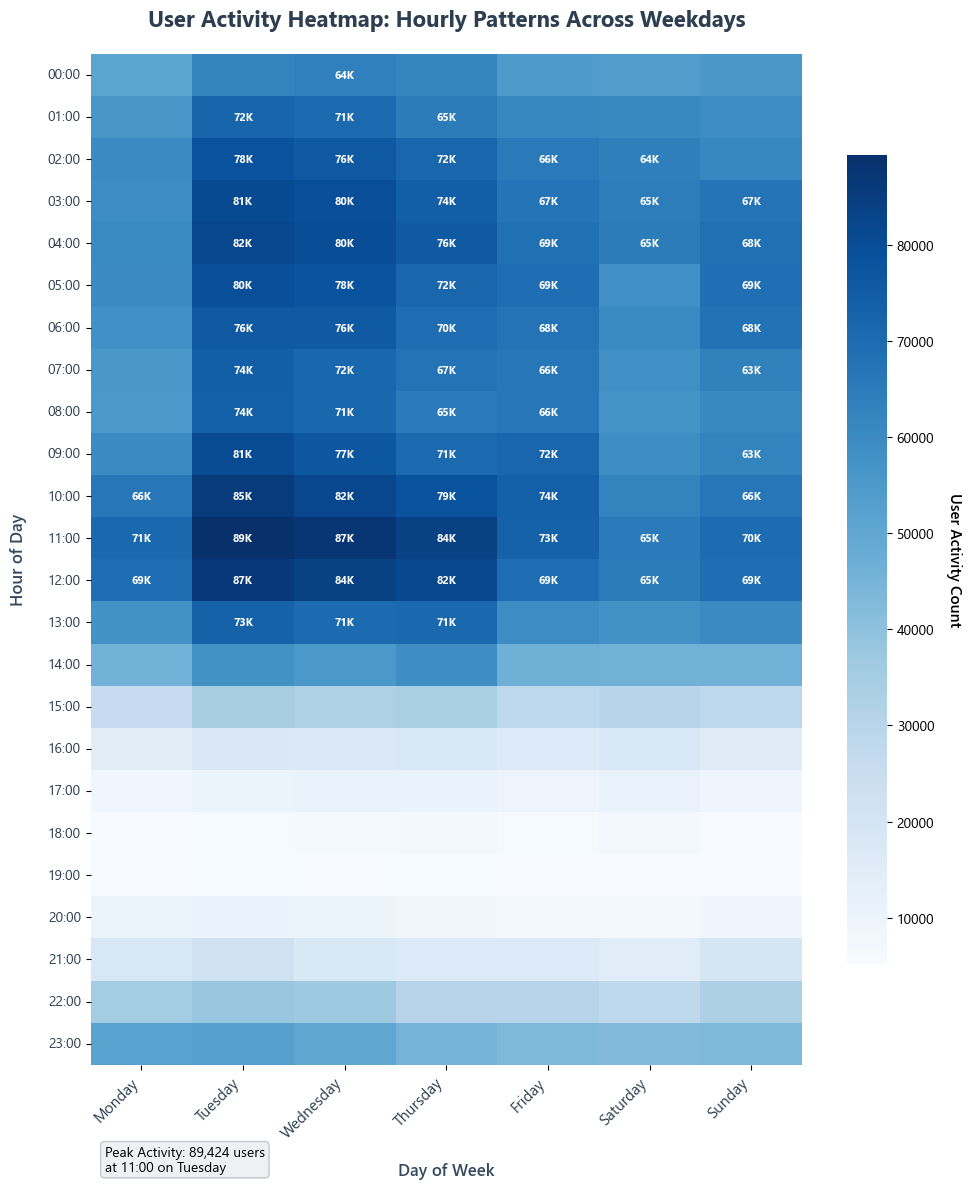

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional style
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white'
})

# Create figure with optimized dimensions
fig, ax = plt.subplots(figsize=(10, 12))

# Create enhanced heatmap with correct color direction (darker = higher values)
heatmap = sns.heatmap(
    pivot_table,
    cmap='Blues',  # Changed to Blues colormap where darker = higher values
    annot=False,      # Keep annotations off for cleaner look
    fmt='.0f',
    cbar_kws={
        'label': 'User Activity Count',
        'shrink': 0.8,
        'format': '%.0f'
    },
    ax=ax,
    linewidths=0,     # No grid lines between cells
    square=False      # Better aspect ratio for time data
)

# Enhanced title
plt.title('User Activity Heatmap: Hourly Patterns Across Weekdays', 
          fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Improved axis labels
plt.xlabel('Day of Week', fontsize=12, fontweight='semibold', 
           color='#34495e', labelpad=15)
plt.ylabel('Hour of Day', fontsize=12, fontweight='semibold', 
           color='#34495e', labelpad=15)

# Enhanced x-axis ticks (weekdays)
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                 'Friday', 'Saturday', 'Sunday']
ax.set_xticks(np.arange(len(weekday_names)) + 0.5)
ax.set_xticklabels(weekday_names, rotation=45, ha='right', 
                   fontsize=11, color='#2c3e50')

# Enhanced y-axis ticks (hours)
hour_labels = [f'{h:02d}:00' for h in range(24)]
ax.set_yticks(np.arange(len(hour_labels)) + 0.5)
ax.set_yticklabels(hour_labels, rotation=0, 
                   fontsize=10, color='#2c3e50')

# Add value annotations for key areas (highest activity)
if pivot_table.max().max() > 0:
    max_val = pivot_table.max().max()
    threshold = max_val * 0.7  # Only annotate high activity cells
    
    for i in range(pivot_table.shape[0]):
        for j in range(pivot_table.shape[1]):
            if pivot_table.iloc[i, j] >= threshold:
                # Format large numbers with K for thousands
                if pivot_table.iloc[i, j] >= 1000:
                    text = f'{pivot_table.iloc[i, j]/1000:.0f}K'
                else:
                    text = f'{pivot_table.iloc[i, j]:.0f}'
                
                # For Blues colormap, use white text on darker cells
                ax.text(j + 0.5, i + 0.5, text,
                       ha='center', va='center',
                       fontsize=8, fontweight='bold',
                       color='white')

# Add descriptive annotation
peak_hour = pivot_table.max(axis=1).idxmax()
peak_day = pivot_table.max(axis=0).idxmax()
peak_value = pivot_table.max().max()

stats_text = f'Peak Activity: {peak_value:,.0f} users\nat {peak_hour:02d}:00 on {peak_day}'
props = dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.9, 
             edgecolor='#bdc3c7', linewidth=1)
ax.text(0.02, -0.08, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Improve colorbar styling
cbar = heatmap.collections[0].colorbar
cbar.set_label('User Activity Count', 
               rotation=270, labelpad=20, 
               fontsize=11, fontweight='semibold')
cbar.ax.tick_params(labelsize=10)

# Remove all spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the enhanced heatmap
plt.show()

# Clean up
plt.close()

## 2.10 Overall-based Analysis of User Behavior Conversion Rates

### 2.10.1 Statistics on the Number of Users with Different Behaviors

In [33]:
user_behavior = oct_data.groupby('event_type')['user_id'].nunique().sort_values(ascending=False)

In [41]:
user_behavior.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/user_behavior/csv/user_behavior.csv', index=True)

C:\Users\86189\AppData\Local\Temp\ipykernel_19376\915766328.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=user_behavior.index, y=user_behavior.values,
C:\Users\86189\AppData\Local\Temp\ipykernel_19376\915766328.py:19: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  bars = sns.barplot(x=user_behavior.index, y=user_behavior.values,


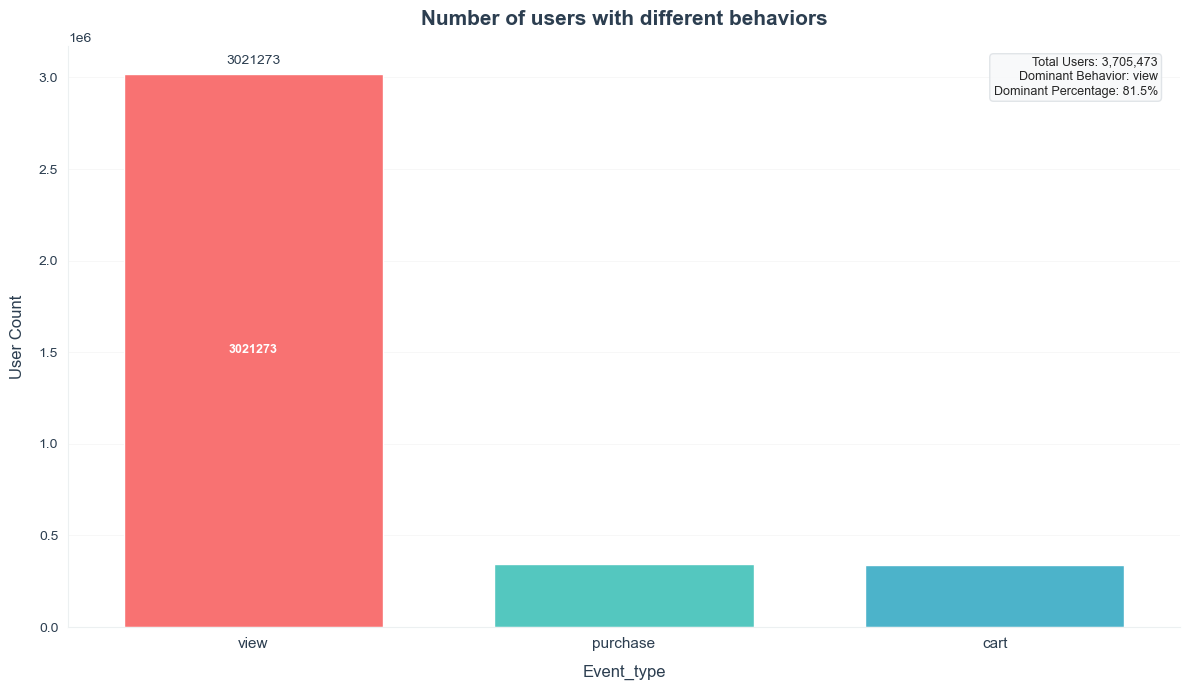

In [50]:

# Set style for modern and clean appearance
plt.style.use('default')
sns.set_style("whitegrid")

# Create figure with professional dimensions
plt.figure(figsize=(12, 7))
fig = plt.gcf()
fig.patch.set_facecolor('white')

# Create axis
ax = plt.gca()
ax.set_facecolor('white')

# Define a vibrant and distinct color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', 
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9']

# Create bar plot with distinct colors
bars = sns.barplot(x=user_behavior.index, y=user_behavior.values, 
                   palette=colors,  # Use our custom vibrant palette
                   saturation=0.9,
                   width=0.7,
                   ax=ax)

# Add clean data labels
ax.bar_label(bars.containers[0], 
             fmt='%d',
             label_type='edge',
             color='#2c3e50',
             fontsize=10,
             fontweight='normal',
             padding=5)

# Professional title
plt.title('Number of users with different behaviors', 
          fontsize=15,
          fontweight='bold',
          pad=15,
          color='#2c3e50')

plt.xlabel('Event_type', 
           fontsize=12,
           fontweight='normal',
           color='#2c3e50',
           labelpad=10)

plt.ylabel('User Count', 
           fontsize=12,
           fontweight='normal',
           color='#2c3e50',
           labelpad=10)


ax.tick_params(axis='x', 
               labelsize=11,
               rotation=0,  # Horizontal labels
               colors='#2c3e50')

# Clean y-axis ticks
ax.tick_params(axis='y', 
               labelsize=10,
               colors='#2c3e50')

# Subtle grid for readability
ax.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Clean spine styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ecf0f1')
ax.spines['bottom'].set_color('#ecf0f1')

# Add value indicators inside bars (where space permits)
for i, container in enumerate(bars.containers):
    for bar in container:
        height = bar.get_height()
        # Only add interior labels if bar is tall enough
        if height > max(user_behavior.values) * 0.15:
            ax.text(bar.get_x() + bar.get_width()/2, height/2, 
                   f'{int(height)}', 
                   ha='center', va='center',
                   fontsize=9, 
                   color='white',
                   fontweight='bold')

# Calculate and display key metrics
total_users = sum(user_behavior.values)
dominant_behavior = user_behavior.idxmax()
dominant_count = user_behavior.max()
dominant_percentage = (dominant_count / total_users) * 100

# Professional annotation box
textstr = f'Total Users: {total_users:,}\nDominant Behavior: {dominant_behavior}\nDominant Percentage: {dominant_percentage:.1f}%'
props = dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, 
             edgecolor='#dee2e6', linewidth=1)

# Position annotation
ax.text(0.98, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=props)

# Perfect the layout
plt.tight_layout()

# Display the optimized visualization
plt.show()

# Clean up
plt.close()

### 2.10.2 Funnel Analysis of User Behaviors

In [52]:
# Original statistics
view_users = set(oct_data.loc[oct_data['event_type'] == 'view', 'user_id'])
cart_users = set(oct_data.loc[oct_data['event_type'] == 'cart', 'user_id'])
purchase_users = set(oct_data.loc[oct_data['event_type'] == 'purchase', 'user_id'])

# Path-based funnel: only users who progressed step by step
view_only = view_users
cart_after_view = cart_users & view_only
purchase_after_cart = purchase_users & cart_after_view

# Users who skipped steps
purchase_after_view = purchase_users & view_only
jumped_cart_users = purchase_after_view - purchase_after_cart

# Build funnel DataFrame
funnel_path = pd.DataFrame({
    'Step': ['view', 'cart (after view)', 'purchase (after cart)'],
    'User Count': [len(view_only), len(cart_after_view), len(purchase_after_cart)]
})

funnel_path['Conversion Rate'] = (funnel_path['User Count'] / funnel_path['User Count'].shift(1)).fillna(1).round(2)

# Additional metrics
jumped_pct = len(jumped_cart_users) / len(purchase_users) if len(purchase_users) else 0
jumped_conversion_rate = len(jumped_cart_users) / len(view_only) if len(view_only) else 0
jumped_text = f"""Percentage of users who skipped cart and purchased directly: {jumped_pct:.2%} ({len(jumped_cart_users)} users)<br>
Conversion rate of users who skipped cart: {jumped_conversion_rate:.2%}"""

funnel_path

,Step,User Count,Conversion Rate
0,view,3021273,1.00
1,cart (after view),336961,0.11
2,purchase (after cart),202739,0.60


In [54]:
funnel_path.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/funnel_path/csv/funnel_path.csv', index=False)

In [55]:
import plotly.graph_objects as go
import pandas as pd

# Prepare data for funnel chart
funnel_data = pd.DataFrame({
    'Stage': ['view', 'cart (after view)', 'purchase (after cart)'],
    'Users': [3021273, 336961, 202739],
    'Initial_Percentage': [100, 11, 7],
    'Previous_Percentage': [100, 11, 60]
})

# Create enhanced funnel chart
fig = go.Figure()

# Add funnel trace with improved styling
fig.add_trace(go.Funnel(
    y=funnel_data['Stage'],
    x=funnel_data['Users'],
    textinfo="value+percent initial+percent previous",
    textposition="inside",
    textfont=dict(
        family="Arial",
        size=14,
        color="white"
    ),
    opacity=0.9,
    marker=dict(
        color=['#6366F1', '#EC4899', '#10B981'],  # Modern color palette
        line=dict(
            color='white',
            width=2
        )
    ),
    connector=dict(
        line=dict(
            color='#D1D5DB',
            width=2,
            dash='dot'
        )
    )
))

# Update layout for professional appearance
fig.update_layout(
    title={
        'text': '<b>User Conversion Funnel Analysis</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24, 'color': '#1F2937', 'family': "Arial"}
    },
    funnelmode="stack",
    height=600,
    width=900,
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(t=80, b=120, l=50, r=50)  # Extra bottom margin for annotations
)

# Add annotations for skipped cart users
fig.add_annotation(
    text=f"<b>Users who skipped cart and purchased directly:</b><br>"
         f"• 41.58% of purchasing users ({144315} users)<br>"
         f"• 4.78% conversion rate from viewers",
    xref="paper", yref="paper",
    x=0.5, y=-0.2,
    xanchor='center',
    showarrow=False,
    font=dict(size=13, color='#374151'),
    bgcolor='#F3F4F6',
    bordercolor='#D1D5DB',
    borderwidth=1,
    borderpad=10
)

# Add data source annotation
fig.add_annotation(
    text="Data represents user progression through conversion stages",
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    xanchor='center',
    showarrow=False,
    font=dict(size=11, color='#6B7280', style='italic')
)

# Customize hover template
fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Users: %{x:,.0f}<br>Initial: %{customdata[0]}%<br>Previous: %{customdata[1]}%<extra></extra>",
    customdata=funnel_data[['Initial_Percentage', 'Previous_Percentage']].values
)

# Show the plot
fig.show()

## 2.11 Analysis of User Behavior Conversion Rates by Product Category

In [14]:
import dask.dataframe as dd
from collections import defaultdict
from tqdm import tqdm

In [10]:
def assign_user_group_partition(partition, n_groups):
    # Note: Here, partition is a pandas.DataFrame
    partition = partition.copy()
    partition.loc[:, 'user_group'] = partition['user_id'].map(lambda x: hash(x) % n_groups)
    return partition

In [11]:
def label_user_sessions_manual(df_session_events):
    results = []  # Store final results, including labels for each session
    # Define nested dictionary structure: user_id -> product_id -> whether it was added to cart (cart status)
    cart_status_dict = defaultdict(lambda: defaultdict(bool))

    # Iterate through each user's session group (grouped by user_id)
    for user_id, group in df_session_events.groupby('user_id', sort=False):
        cart_status = cart_status_dict[user_id]  # Cart status records for the current user
        user_results = []  # Labels for all sessions of the current user

        # Iterate through all sessions of the current user (one session per row)
        for row in group.itertuples(index=False):
            events = row.event_product_seq  # Behavior sequence of the current session (event, product_id)
            session_cart = set()     # Set of products added to cart in the current session
            session_purchase = set() # Set of purchased products in the current session

            # Collect product IDs for cart and purchase behaviors in the current session
            for evt, pid in events:
                if evt == 'cart':
                    session_cart.add(pid)
                elif evt == 'purchase':
                    session_purchase.add(pid)

            # Initialize session label
            label = 'only_view'
            matched = False  # Used to mark if it matches previous cart status

            # Prioritize checking for "cart_purchase"
            for pid in session_purchase:
                if cart_status[pid]:  # If the product was added to cart in previous sessions
                    label = 'cart_purchase'
                    cart_status[pid] = False  # Clear status to avoid affecting subsequent sessions
                    matched = True
                    break  # Exit once matched (conservative judgment)

            # If no cart status matched
            if not matched:
                if session_purchase:
                    label = 'view_purchase'  # Has purchases but no cart additions
                elif session_cart:
                    label = 'view_cart'  # Only has cart addition behaviors
                    # Record all cart products in current session as status for subsequent sessions
                    for pid in session_cart:
                        cart_status[pid] = True

            # Save label result for current session
            user_results.append((user_id, row.user_session, label))

        # Merge labeling results for all sessions of the current user
        results.extend(user_results)

    # Convert to DataFrame and return
    return pd.DataFrame(results, columns=['user_id', 'user_session', 'purchase_path'])

In [19]:
def process_user_behavior_paths_to_disk(dask_df, n_groups=10, save_dir="session_path_parts", show_progress=True):
    os.makedirs(save_dir, exist_ok=True)
    df = dask_df.map_partitions(assign_user_group_partition, n_groups=n_groups)

    iterator = tqdm(range(n_groups), desc="Processing user groups") if show_progress else range(n_groups)

    for group_id in iterator:
        part_ddf = df[df['user_group'] == group_id]
        part_df = part_ddf.compute()
        part_df = part_df.sort_values(['user_id', 'event_time_ts'])

        session_events = part_df.groupby(['user_id', 'user_session']).apply(
            lambda x: list(zip(x['event_type'], x['product_id']))
        ).reset_index(name='event_product_seq')

        part_result = label_user_sessions_manual(session_events)

        part_result.to_parquet(f"{save_dir}/session_path_group_{group_id}.parquet", index=False)

        del part_df, session_events, part_result
        gc.collect()

    print(f"\n 所有 session_path 保存完毕于：{save_dir}/")

def load_all_session_paths(save_dir="session_path_parts"):
    files = sorted([os.path.join(save_dir, f) for f in os.listdir(save_dir) if f.endswith(".parquet")])
    dfs = [pd.read_parquet(f) for f in files]
    return pd.concat(dfs, ignore_index=True)

In [20]:
# 1. Prepare data
dask_behavior = dd.from_pandas(oct_data[['user_id', 'user_session', 'event_time_ts', 'event_type', 'product_id']], npartitions=10)

# 2. Execute labeling
process_user_behavior_paths_to_disk(dask_behavior, n_groups=20, save_dir="session_parts")

del dask_behavior
gc.collect()

Processing user groups:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\86189\AppData\Local\Temp\ipykernel_19376\1205733951.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_events = part_df.groupby(['user_id', 'user_session']).apply(
Processing user groups:   5%|▌         | 1/20 [03:52<1:13:31, 232.20s/it]C:\Users\86189\AppData\Local\Temp\ipykernel_19376\1205733951.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to si

0

In [21]:
session_paths = load_all_session_paths("session_parts")

# Merge back into the original data
oct_data_merged = oct_data.merge(session_paths, on=["user_id", "user_session"])

In [22]:
oct_data_merged.head(5)


,event_time_ts,event_type,product_id,category_code,brand,price,user_id,user_session,is_category_missing,is_brand_missing,is_price_outlier,date,hour,weekday,weekday_name,is_weekend,week_in_month,purchase_path
0,2019-09-30T22:39:37.000-04:00,view,32200019,kids.swing,unknown,247.11,555465042,d03cf681-d8c5-4b39-b914-0c776ce42233,0,1,0,2019-09-30,22,0,Monday,0,1,only_view
1,2019-09-30T23:28:23.000-04:00,view,3601475,appliances.kitchen.washer,lg,536.83,516327686,9c553f91-3a25-4443-96b0-393006d6c5e2,0,0,0,2019-09-30,23,0,Monday,0,1,only_view
2,2019-09-30T22:44:57.000-04:00,view,4201337,appliances.environment.air_conditioner,tcl,177.61,553846897,8e566957-748f-493a-a5a2-190f2fb5dbfd,0,0,0,2019-09-30,22,0,Monday,0,1,only_view
3,2019-09-30T22:44:42.000-04:00,view,4802930,electronics.audio.headphone,elari,51.46,551055706,35292171-8f0e-402f-9a99-f074b9bb650b,0,0,0,2019-09-30,22,0,Monday,0,1,only_view
4,2019-09-30T23:37:16.000-04:00,view,14701162,furniture.living_room.cabinet,unknown,411.85,535520240,d9b00871-1b48-4131-9283-534b6fd89df9,0,1,0,2019-09-30,23,0,Monday,0,1,only_view


In [ ]:
oct_data_merged.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/oct_data_merged/csv/oct_data_merged.csv', index=False)

### 2.11.1 Analysis of User Cart Addition Rate by Product Category

In [71]:
input_path_view2cart = r"D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/category_conversion_rates/csv/part-00000-cedf727b-0279-47e4-be84-b564226dd9d7-c000.csv"
session_count = pd.read_csv(input_path_view2cart)

In [72]:
sort_df = session_count.sort_values(by=['view2cart_ratio'], ascending=False)
sort_df.head(10)

,category_code,view,cart,purchase,view2cart_ratio
62,electronics.smartphone,10613866,531984,337979,0.050122
9,electronics.audio.headphone,1017621,49885,30501,0.049021
27,medicine.tools.tonometer,13962,514,310,0.036814
79,electronics.video.tv,1054901,35023,21561,0.033200
12,electronics.tablet,301822,8801,5602,0.029160
51,appliances.kitchen.microwave,164796,4627,3708,0.028077
90,appliances.environment.water_heater,138558,3786,2774,0.027324
107,appliances.iron,157489,3965,3652,0.025176
123,appliances.kitchen.washer,830729,20864,16146,0.025115
89,computers.peripherals.printer,145466,3564,2496,0.024501


C:\Users\86189\AppData\Local\Temp\ipykernel_19376\1421693589.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




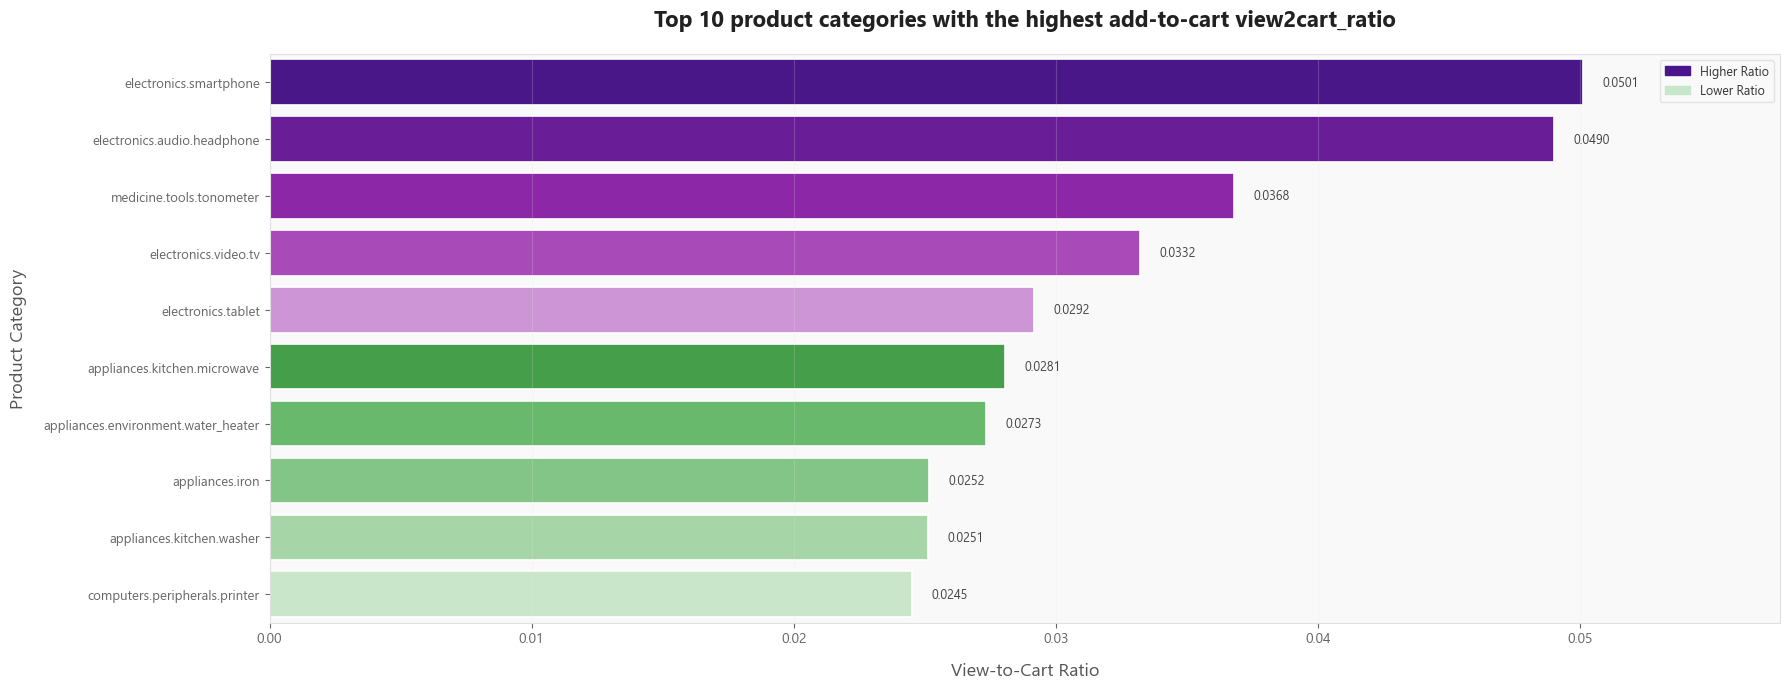

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('view2cart_ratio', ascending=False).head(10)
categories = sort_df['category_code']

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['view2cart_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product categories with the highest add-to-cart view2cart_ratio',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'View-to-Cart Ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    loc='center'
)

plt.ylabel(
    'Product Category',
    fontsize=13,
    labelpad=12,
    color='#555555',
    loc='center'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['view2cart_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["view2cart_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['view2cart_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()

### 2.11.2 Analysis of User Conversion Rate from Cart Addition to Purchase by Product Category

In [5]:
oct_data_merged = pd.read_csv("D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/oct_data_merged/csv/oct_data_merged.csv")

In [7]:
session_count = oct_data_merged.groupby(['category_code', 'purchase_path'])['user_session'].count().unstack().fillna(0)
session_count['cart'] = session_count['view_cart'] + session_count['cart_purchase']
session_count.head()

purchase_path,cart_purchase,only_view,view_cart,view_purchase,cart
category_code,,,,,
accessories.bag,228.0,172777.0,3743.0,13255.0,3971.0
accessories.umbrella,2.0,3619.0,60.0,242.0,62.0
accessories.wallet,52.0,39555.0,373.0,3496.0,425.0
apparel.belt,5.0,2200.0,17.0,207.0,22.0
apparel.costume,33.0,126824.0,849.0,5492.0,882.0


In [8]:
sort_df = pd.DataFrame({
    'cart_count': session_count['cart'], 
    'cart2purchase_count': session_count['cart_purchase']
}, index=session_count.index)

sort_df['cart2purchase_ratio'] = np.where(
    sort_df['cart_count'] != 0, 
    sort_df['cart2purchase_count'] / sort_df['cart_count'], 
    0
)

In [14]:
sort_df.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/cart2purchase_ratio/csv/cart2purchase_ratio.csv', index=True)

In [17]:
sort_df = sort_df.sort_values(by=['cart2purchase_ratio'], ascending=False)
sort_df.head(10)

,cart_count,cart2purchase_count,cart2purchase_ratio
category_code,,,
apparel.belt,22.0,5.0,0.227273
sport.snowboard,58.0,10.0,0.172414
sport.ski,36.0,6.0,0.166667
accessories.wallet,425.0,52.0,0.122353
auto.accessories.parktronic,190.0,21.0,0.110526
apparel.trousers,146.0,14.0,0.095890
electronics.audio.headphone,121277.0,11280.0,0.093010
apparel.scarf,22.0,2.0,0.090909
appliances.personal.massager,722.0,65.0,0.090028


C:\Users\86189\AppData\Local\Temp\ipykernel_13628\1614287904.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


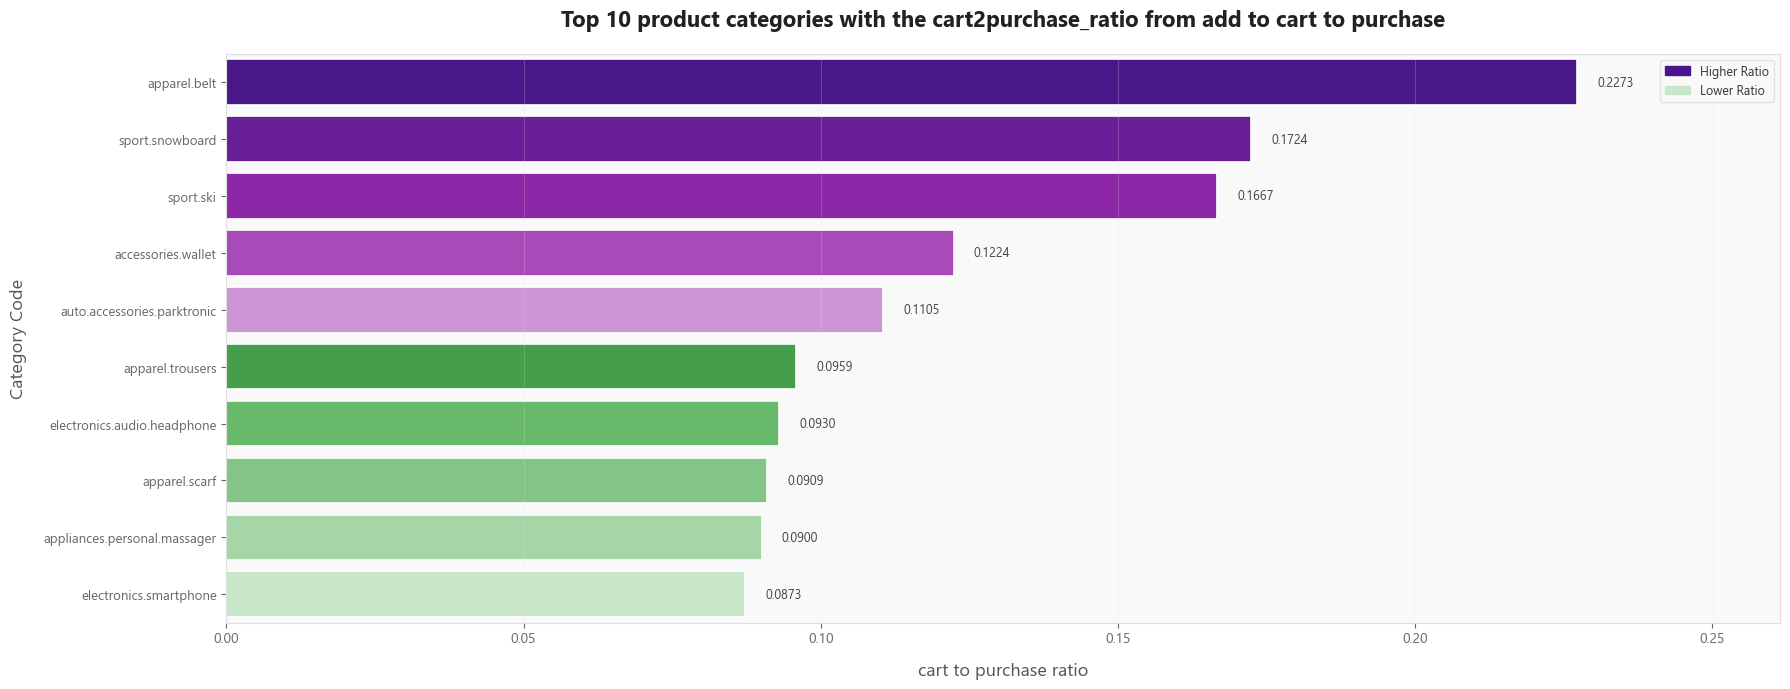

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('cart2purchase_ratio', ascending=False).head(10)
categories = sort_df.index

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['cart2purchase_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product categories with the cart2purchase_ratio from add to cart to purchase',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'cart to purchase ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    
)

plt.ylabel(
    'Category Code',
    fontsize=13,
    labelpad=12,
    color='#555555'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['cart2purchase_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["cart2purchase_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['cart2purchase_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()

### 2.11.3 Analysis of User Conversion Rate from Browsing to Purchase by Product Category (Skipping the Cart Addition Step)

In [24]:
session_count['view'] = session_count['view_purchase'] + session_count['only_view'] + session_count['view_cart']
session_count.head()

purchase_path,cart_purchase,only_view,view_cart,view_purchase,cart,view
category_code,,,,,,
accessories.bag,228.0,172777.0,3743.0,13255.0,3971.0,189775.0
accessories.umbrella,2.0,3619.0,60.0,242.0,62.0,3921.0
accessories.wallet,52.0,39555.0,373.0,3496.0,425.0,43424.0
apparel.belt,5.0,2200.0,17.0,207.0,22.0,2424.0
apparel.costume,33.0,126824.0,849.0,5492.0,882.0,133165.0


In [25]:
sort_df = pd.DataFrame({
    'view_count': session_count['view'], 
    'view2purchase_count': session_count['view_purchase']
}, index=session_count.index)

sort_df['view2purchase_ratio'] = np.where(
    sort_df['view_count'] != 0, 
    sort_df['view2purchase_count'] / sort_df['view_count'], 
    0
)

In [26]:
sort_df.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/view2purchase_ratio/csv/view2purchase_ratio.csv', index=True)

In [27]:
sort_df = sort_df.sort_values(by=['view2purchase_ratio'], ascending=False)
sort_df.head(10)

,view_count,view2purchase_count,view2purchase_ratio
category_code,,,
appliances.personal.scales,65034.0,10206.0,0.156933
appliances.iron,164280.0,25332.0,0.154200
electronics.smartphone,11386928.0,1753814.0,0.154020
appliances.kitchen.microwave,172326.0,25983.0,0.150778
kids.fmcg.diapers,25018.0,3549.0,0.141858
electronics.audio.headphone,1086727.0,150662.0,0.138638
medicine.tools.tonometer,14750.0,1966.0,0.133288
appliances.ironing_board,35148.0,4674.0,0.132981
appliances.kitchen.kettle,183960.0,23967.0,0.130284


C:\Users\86189\AppData\Local\Temp\ipykernel_13628\3385854602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


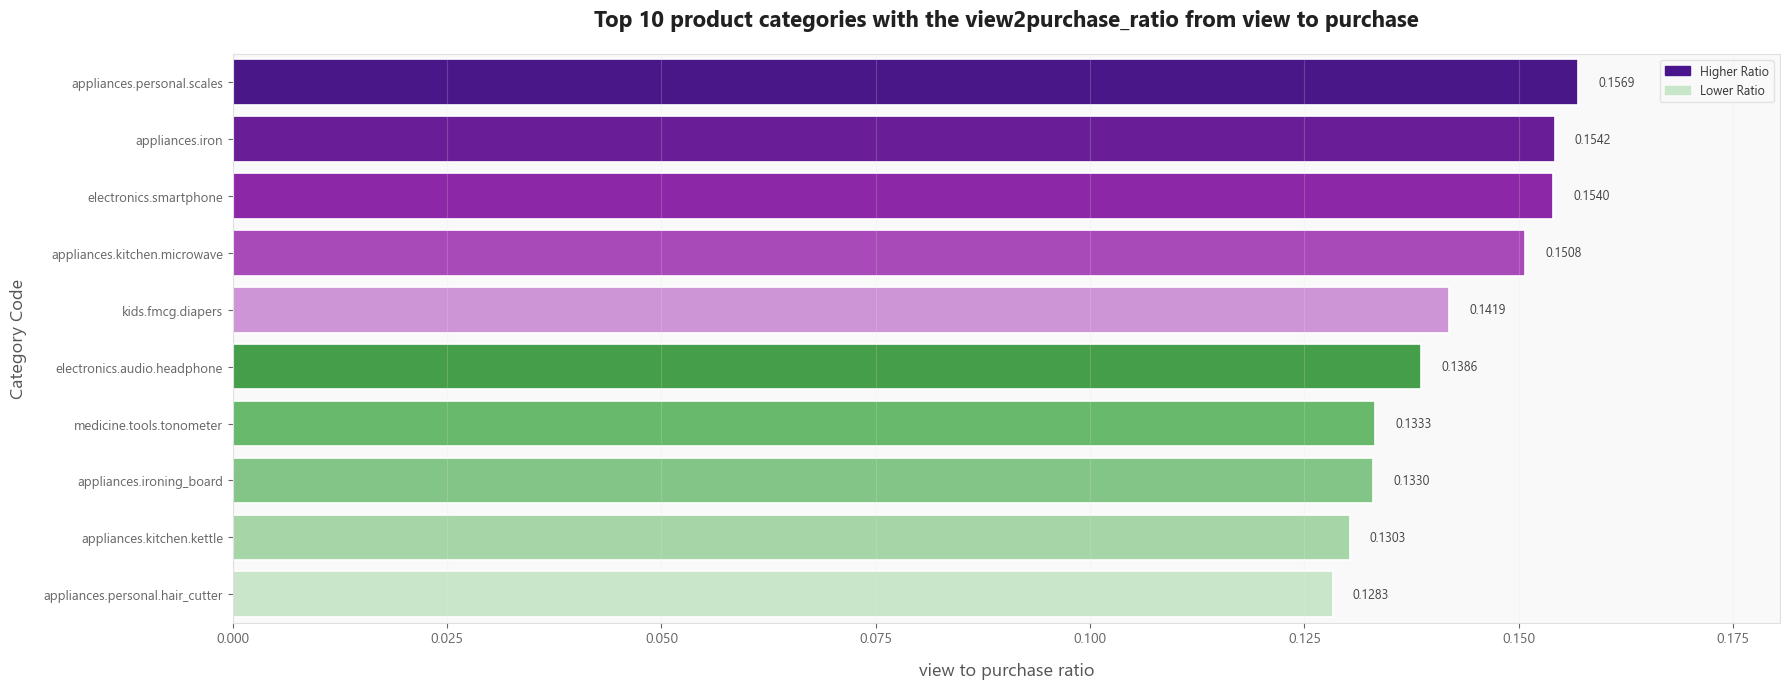

In [28]:
# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('view2purchase_ratio', ascending=False).head(10)
categories = sort_df.index

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['view2purchase_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product categories with the view2purchase_ratio from view to purchase',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'view to purchase ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    
)

plt.ylabel(
    'Category Code',
    fontsize=13,
    labelpad=12,
    color='#555555'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['view2purchase_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["view2purchase_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['view2purchase_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()

## 2.12 Analysis of User Behavior Conversion Rates by Product Brand

### 2.12.1 Analysis of User Cart Addition Rate by Product Brand

In [31]:
session_count_brand = oct_data_merged.groupby(['brand', 'event_type'])['user_session'].count().unstack().fillna(0)

In [32]:
session_count_brand['view2cart_ratio'] = session_count_brand['cart'] / session_count_brand['view']
session_count_brand.head()

event_type,cart,purchase,view,view2cart_ratio
brand,,,,
a-case,19.0,58.0,6779.0,0.002803
a-derma,0.0,1.0,297.0,0.000000
a-elita,0.0,0.0,201.0,0.000000
a-mega,0.0,9.0,542.0,0.000000
aardwolf,0.0,0.0,48.0,0.000000


In [36]:
session_count_brand.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/view2cart_ratio_brand/csv/view2cart_ratio_brand.csv', index=True)

In [45]:
sort_df = session_count_brand.sort_values(by=['view2cart_ratio'], ascending=False)
sort_df.head(10)

event_type,cart,purchase,view,view2cart_ratio
brand,,,,
ea,1823.0,681.0,13024.0,0.139972
diamond,44.0,20.0,594.0,0.074074
samsung,292038.0,172878.0,4806255.0,0.060762
homeelement,6.0,0.0,101.0,0.059406
steba,5.0,2.0,85.0,0.058824
domyos,128.0,45.0,2178.0,0.058770
goo.n,53.0,19.0,933.0,0.056806
sonyinteractiveentertainment,55.0,21.0,985.0,0.055838
apple,203757.0,142858.0,3770366.0,0.054042


C:\Users\86189\AppData\Local\Temp\ipykernel_13628\3082611681.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


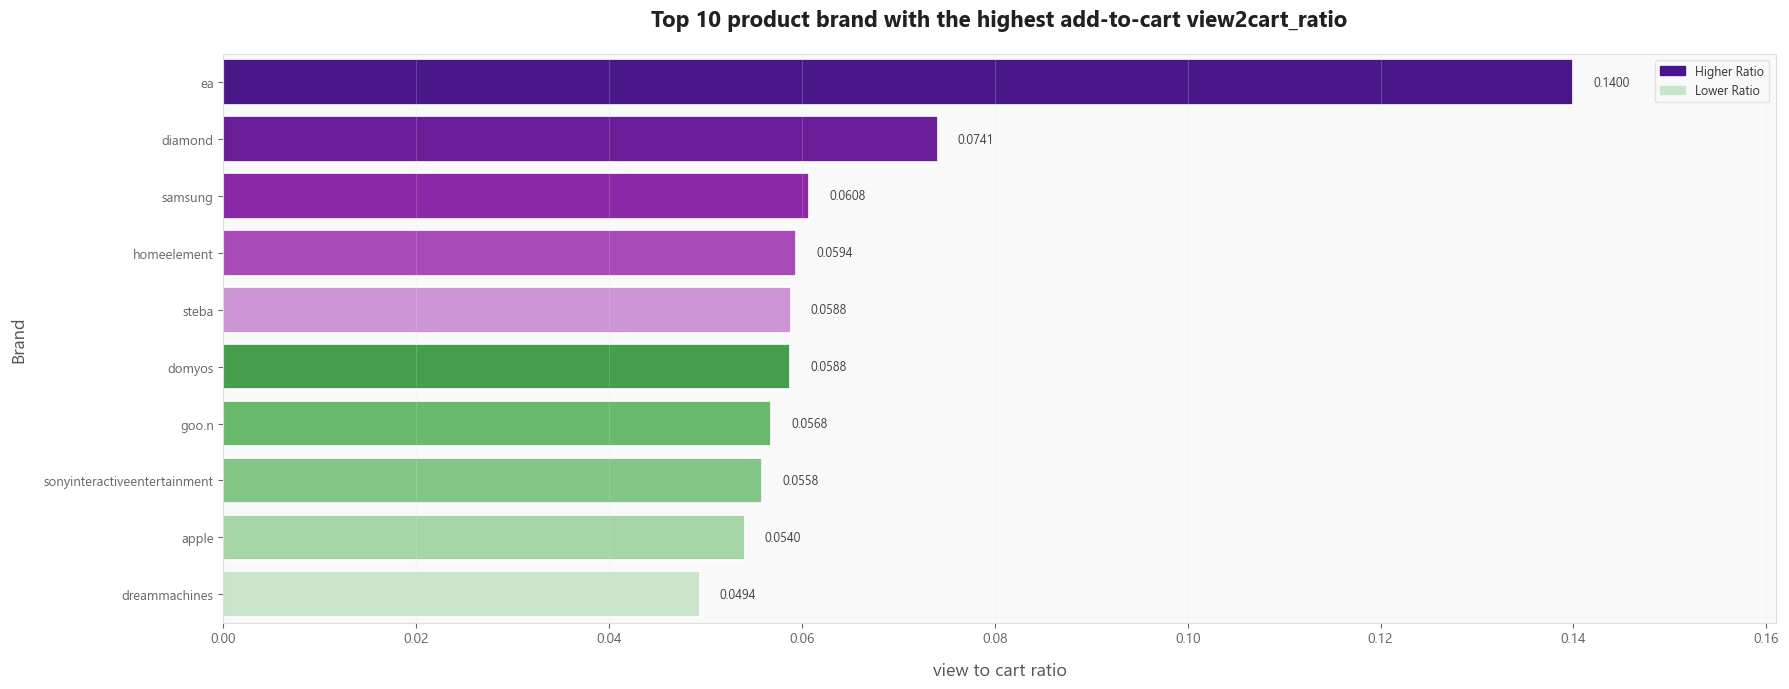

In [46]:
# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('view2cart_ratio', ascending=False).head(10)
categories = sort_df.index

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['view2cart_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product brand with the highest add-to-cart view2cart_ratio',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'view to cart ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    
)

plt.ylabel(
    'Brand',
    fontsize=13,
    labelpad=12,
    color='#555555'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['view2cart_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["view2cart_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['view2cart_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()

### 2.12.2 Analysis of User Conversion Rate from Cart Addition to Purchase by Product Brand

In [39]:
session_count = oct_data_merged.groupby(['brand', 'purchase_path'])['user_session'].count().unstack().fillna(0)
session_count['cart'] = session_count['view_cart'] + session_count['cart_purchase']
session_count.head()

purchase_path,cart_purchase,only_view,view_cart,view_purchase,cart
brand,,,,,
a-case,8.0,6130.0,253.0,465.0,261.0
a-derma,0.0,261.0,1.0,36.0,1.0
a-elita,0.0,194.0,0.0,7.0,0.0
a-mega,0.0,493.0,2.0,56.0,2.0
aardwolf,0.0,45.0,0.0,3.0,0.0


In [47]:
sort_df = pd.DataFrame({
    'cart_count': session_count['cart'], 
    'cart2purchase_count': session_count['cart_purchase']
}, index=session_count.index)

sort_df['cart2purchase_ratio'] = np.where(
    sort_df['cart_count'] != 0, 
    sort_df['cart2purchase_count'] / sort_df['cart_count'], 
    0
)

In [42]:
sort_df.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/cart2purchase_ratio_brand/csv/cart2purchase_ratio_brand.csv', index=True)

In [48]:
sort_df.sort_values(by=['cart2purchase_ratio'], ascending=False, inplace=True)
sort_df.head(10)

,cart_count,cart2purchase_count,cart2purchase_ratio
brand,,,
worwo,1.0,1.0,1.0
solarstorm,1.0,1.0,1.0
mebberykz,1.0,1.0,1.0
ol-tex,3.0,3.0,1.0
schecter,1.0,1.0,1.0
giornonotte,3.0,3.0,1.0
daewooelectronics,1.0,1.0,1.0
beisier,1.0,1.0,1.0
crisa,1.0,1.0,1.0


C:\Users\86189\AppData\Local\Temp\ipykernel_13628\1970244672.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


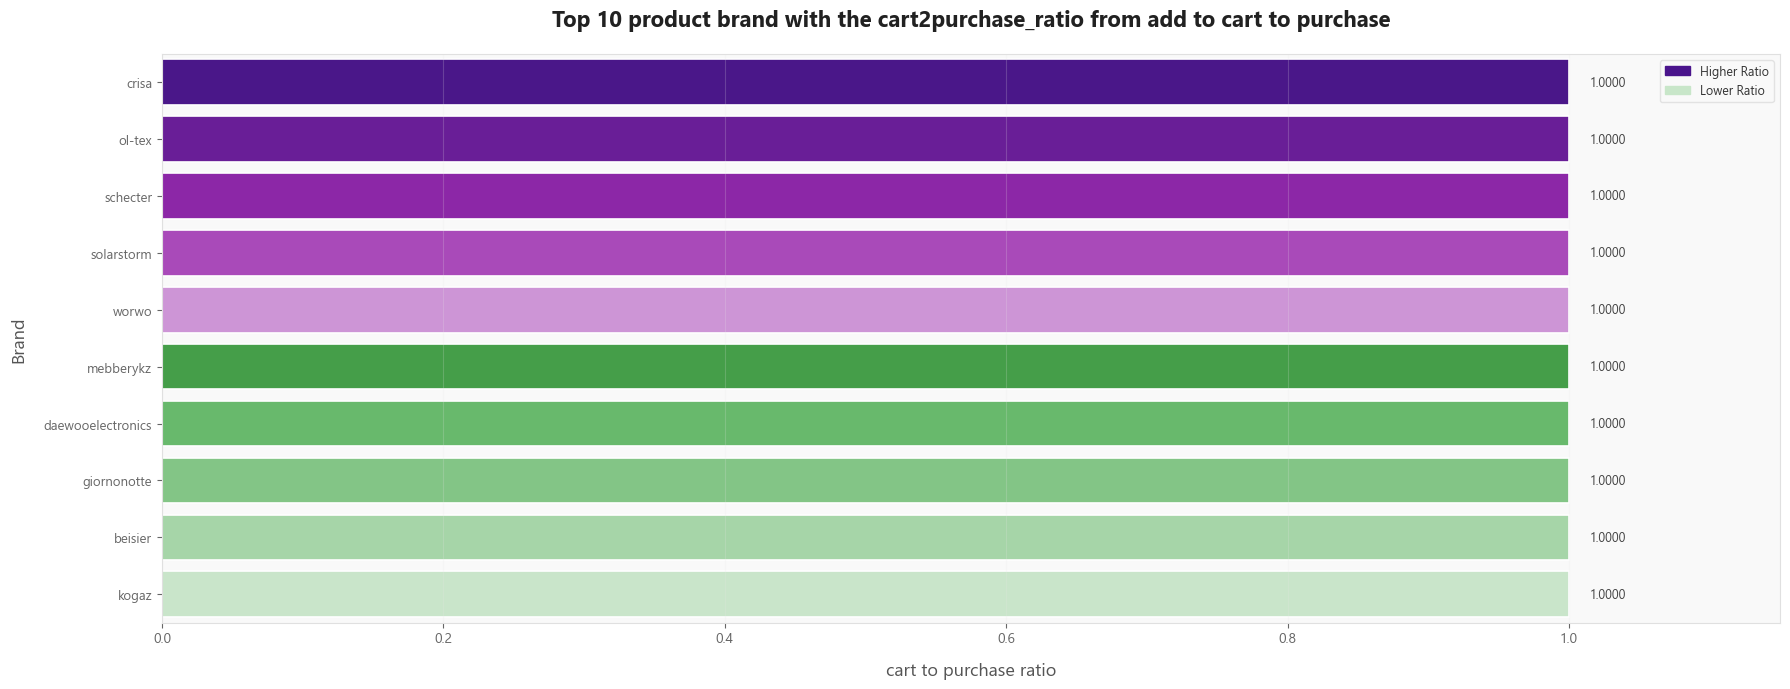

In [49]:
# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('cart2purchase_ratio', ascending=False).head(10)
categories = sort_df.index

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['cart2purchase_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product brand with the cart2purchase_ratio from add to cart to purchase',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'cart to purchase ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    
)

plt.ylabel(
    'Brand',
    fontsize=13,
    labelpad=12,
    color='#555555'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['cart2purchase_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["cart2purchase_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['cart2purchase_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()

### 2.12.3 Analysis of User Conversion Rate from Browsing to Purchase by Product Brand (Skipping the Cart Addition Step)

In [50]:
session_count['view'] = session_count['view_purchase'] + session_count['only_view'] + session_count['view_cart']
session_count.head()

purchase_path,cart_purchase,only_view,view_cart,view_purchase,cart,view
brand,,,,,,
a-case,8.0,6130.0,253.0,465.0,261.0,6848.0
a-derma,0.0,261.0,1.0,36.0,1.0,298.0
a-elita,0.0,194.0,0.0,7.0,0.0,201.0
a-mega,0.0,493.0,2.0,56.0,2.0,551.0
aardwolf,0.0,45.0,0.0,3.0,0.0,48.0


In [51]:
sort_df = pd.DataFrame({
    'view_count': session_count['view'], 
    'view2purchase_count': session_count['view_purchase']
}, index=session_count.index)

sort_df['view2purchase_ratio'] = np.where(
    sort_df['view_count'] != 0, 
    sort_df['view2purchase_count'] / sort_df['view_count'], 
    0
)

In [52]:
sort_df.to_csv('D:/semA/CS5488BigData/project/ecommerce_oct/ecommerce_oct/view2purchase_ratio_brand/csv/view2purchase_ratio_brand.csv', index=True)

In [53]:
sort_df.sort_values(by=['view2purchase_ratio'], ascending=False, inplace=True)
sort_df.head(10)

,view_count,view2purchase_count,view2purchase_ratio
brand,,,
ashleyfurniture,2.0,2.0,1.000000
zazu,1.0,1.0,1.000000
yoobao,1.0,1.0,1.000000
magkijson,3.0,3.0,1.000000
lamelprofessional,4.0,3.0,0.750000
timbergroup,14.0,10.0,0.714286
zhejiang,10.0,7.0,0.700000
kuqidai,6.0,4.0,0.666667
plamers,9.0,6.0,0.666667


C:\Users\86189\AppData\Local\Temp\ipykernel_13628\380441435.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


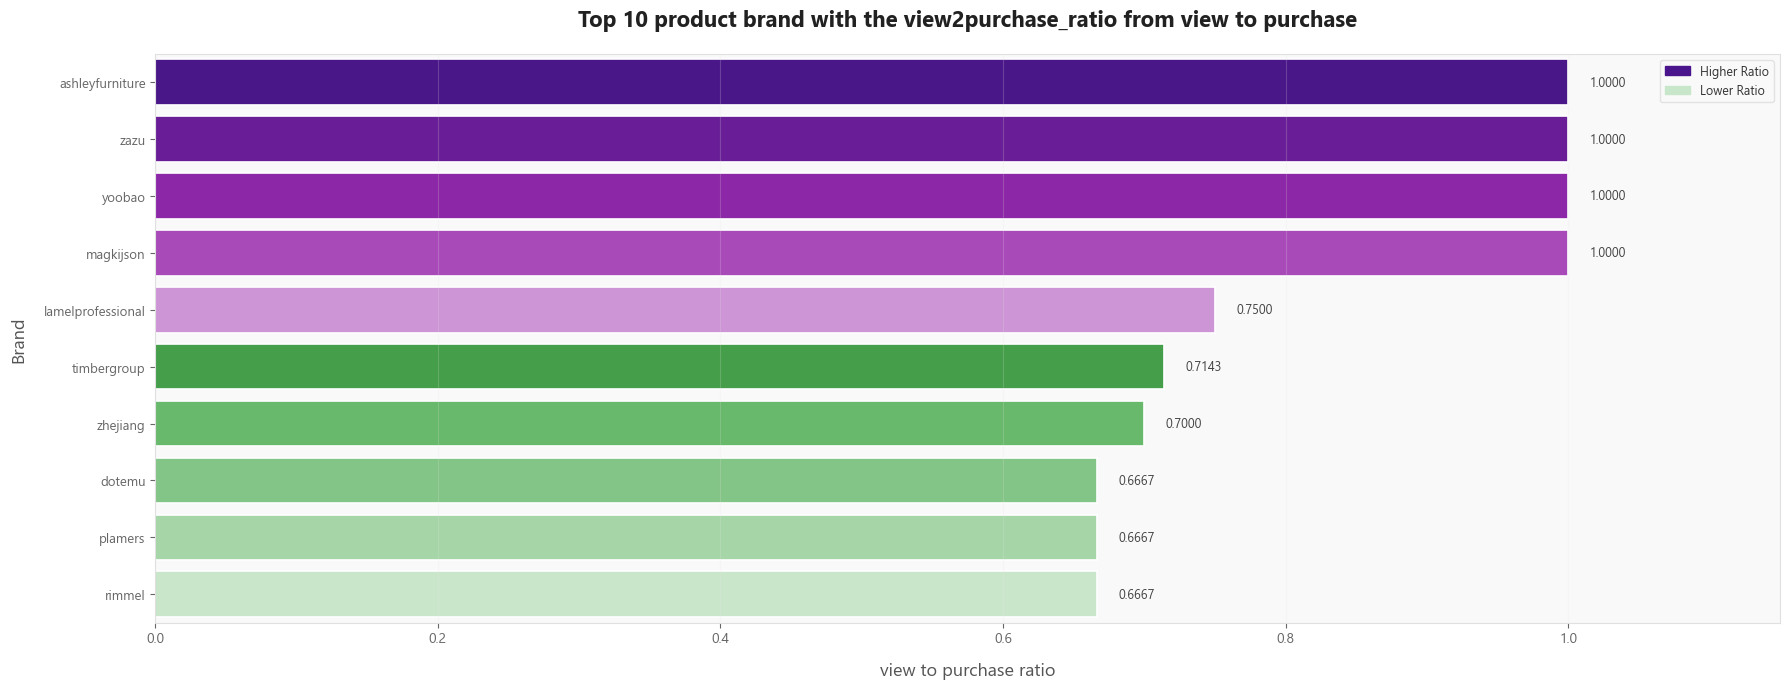

In [54]:
# Ensure data is sorted correctly (core prerequisite)
sort_df = sort_df.sort_values('view2purchase_ratio', ascending=False).head(10)
categories = sort_df.index

# --------------------------
# Global style settings (establish an elegant tone)
# --------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Segoe UI, Arial, sans-serif',  # Modern sans-serif fonts for a more professional look
    'axes.facecolor': '#f9f9f9',  # Ultra-light gray background, softer than pure white
    'axes.edgecolor': '#e0e0e0',  # Light gray border to soften edges
    'grid.color': '#e8e8e8',      # Light gray grid lines, nearly invisible but assist in reading values
    'text.color': '#333333',      # Dark gray text, not harsh on the eyes
    'xtick.color': '#666666',
    'ytick.color': '#666666'
})

# Canvas size: height fits 10 categories, width leaves enough space for data labels
plt.figure(figsize=(18, 7))

# --------------------------
# Draw bar plot (core visual optimization)
# --------------------------
# Custom gradient colors: from dark purple to light green, with soft transitions and high distinguishability
colors = sns.color_palette(['#4a148c', '#6a1b9a', '#8e24aa', '#ab47bc', '#ce93d8',
                            '#43a047', '#66bb6a', '#81c784', '#a5d6a7', '#c8e6c9'])

bar_plot = sns.barplot(
    x=sort_df['view2purchase_ratio'],
    y=categories,
    palette=colors,
    edgecolor='white',       # White border to clearly separate bars
    linewidth=1.2,           # Slightly wider border to enhance separation
    saturation=0.95          # Slightly reduced color saturation to avoid harshness
)

# --------------------------
# Title and labels (clear hierarchy)
# --------------------------
plt.title(
    'Top 10 product brand with the view2purchase_ratio from view to purchase',
    fontsize=16,
    fontweight='bold',
    pad=20,  # Spacing between title and plot
    loc='center',
    color='#212121'
)

plt.xlabel(
    'view to purchase ratio',
    fontsize=13,
    labelpad=12,
    color='#555555',
    
)

plt.ylabel(
    'Brand',
    fontsize=13,
    labelpad=12,
    color='#555555'
)

# Tick labels: category names slightly smaller to avoid crowding; value ticks clear
plt.xticks(fontsize=10)
plt.yticks(fontsize=9.5)  # Category names slightly smaller to fit long names

# --------------------------
# Data labels (elegant and non-intrusive)
# --------------------------
for i, bar in enumerate(bar_plot.patches):
    # Position of value labels: right side of bars + slight offset, vertically centered
    x_pos = bar.get_width() + (sort_df['view2purchase_ratio'].max() * 0.015)
    y_pos = bar.get_y() + bar.get_height() / 2
    # Value format: 4 decimal places, elegant font
    plt.text(
        x_pos, y_pos,
        f'{sort_df["view2purchase_ratio"].iloc[i]:.4f}',
        va='center',
        fontsize=9,
        color='#444444',
        fontweight='500'  # Semi-bold, more prominent than regular text
    )

# --------------------------
# Detail decorations (enhance texture)
# --------------------------
# X-axis range: starts from 0, 15% space on the right for data labels
plt.xlim(0, sort_df['view2purchase_ratio'].max() * 1.15)

# Keep only x-axis grid lines with very low transparency
plt.grid(axis='x', linestyle='-', alpha=0.2)

# Add a thin border to the plot to enhance integrity
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.8)

# Optional: add a small legend at the top (if color logic needs explanation)
if len(colors) > 1:
    legend_items = [mpatches.Patch(color=colors[0], label='Higher Ratio'),
                    mpatches.Patch(color=colors[-1], label='Lower Ratio')]
    plt.legend(handles=legend_items, loc='upper right', frameon=True,
               framealpha=0.9, fontsize=9, edgecolor='#e0e0e0')

# Automatically adjust layout to ensure all elements are visible
plt.tight_layout()

plt.show()